# Semantic Log Debugger & Causal RCA Pipeline
This notebook implements a Cognitive Software Debugger for HDFS logs using:
1. **Semantic Vector Embeddings** (Sentence-Transformers)
2. **Vector Similarity Search** (FAISS)
3. **Causal Dependency Graphs** (NetworkX)

### Setup & Configurations

In [7]:
# INSTALL PROJECT DEPENDENCIES
# This cell installs all required AI and visualization libraries from requirements.txt.
import sys
print("Installing dependencies from requirements.txt...")
!{sys.executable} -m pip install -r requirements.txt --quiet
!{sys.executable} -m pip install -U sentence-transformers
!{sys.executable} -m pip install --upgrade --force-reinstall datasets transformers huggingface_hub accelerate

print("\n--- INSTALLATION COMPLETE ---")
print("ACTION: If you updated libraries, please RESTART THE KERNEL!")

Installing dependencies from requirements.txt...



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached sentence_transformers-5.3.0-py3-none-any.whl.metadata (16 kB)
Using cached sentence_transformers-5.3.0-py3-none-any.whl (512 kB)
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 2.6.1
    Uninstalling sentence-transformers-2.6.1:
      Successfully uninstalled sentence-transformers-2.6.1



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached datasets-4.8.4-py3-none-any.whl.metadata (19 kB)
  Using cached transformers-5.5.0-py3-none-any.whl.metadata (32 kB)
  Using cached huggingface_hub-1.9.0-py3-none-any.whl.metadata (14 kB)
  Using cached accelerate-1.13.0-py3-none-any.whl.metadata (19 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached pyarrow-23.0.1-cp312-cp312-win_amd64.whl.metadata (3.1 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached pandas-3.0.2-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached xxhash-3.6.0-cp312-cp312-win_amd64.whl.metadata (13 kB)
  Using cached multiprocess-0.70.19-py312-none-any.whl.metadata (7.5 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metada

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-api-core 2.30.0 requires protobuf<7.0.0,>=4.25.8, but you have protobuf 7.34.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.34.1 which is incompatible.
numba 0.62.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.
op

In [2]:
import os
import re
import json
import random
import sys
import subprocess
import pandas as pd
import numpy as np
import faiss
import networkx as nx
import torch
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm.notebook import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer

try:
    from sentence_transformers import SentenceTransformer
except Exception:
    SentenceTransformer = None

from pyvis.network import Network
from IPython.display import display, IFrame

# Directory Setup
INPUT_DIR = "dataset"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# File Paths
DATASET_FILE = os.path.join(INPUT_DIR, "HDFS_2k.log_structured.csv")
TRACES_FILE = os.path.join(OUTPUT_DIR, "structured_traces.json")
TEMPLATES_FILE = os.path.join(OUTPUT_DIR, "extracted_templates.json")
RCA_RESULTS_FILE = os.path.join(OUTPUT_DIR, "rca_results.json")
ANOMALIES_FILE = os.path.join(OUTPUT_DIR, "anomalous_traces.json")
FAISS_INDEX_FILE = os.path.join(OUTPUT_DIR, "faiss_index.bin")
MAPPING_FILE = os.path.join(OUTPUT_DIR, "template_mapping.json")

print("Project initialized with dataset and output directories.")
rca_results = {}

c:\1Data\Ved_Data\AmritaCSE\Research\Research_Sem5\ML_DL_FetusScan\ML_Endsem\venv\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange



Project initialized with dataset and output directories.


## Stage 1: Data Preprocessing
Loading the structured dataset and grouping logs by `block_id`.

In [3]:
def extract_block_id(content):
    match = re.search(r'(blk_-?\d+)', str(content))
    return match.group(1) if match else None

print(f"Loading dataset: {DATASET_FILE}")
df = pd.read_csv(DATASET_FILE)

print("\n--- Sample Dataset Record ---")
display(df.head())

traces = defaultdict(list)
templates_set = set()

for _, row in tqdm(df.iterrows(), total=len(df), desc="Grouping Logs"):
    block_id = extract_block_id(row['Content'])
    if block_id:
        traces[block_id].append(row['EventTemplate'])
        templates_set.add(row['EventTemplate'])

templates_dict = {str(i): t for i, t in enumerate(sorted(list(templates_set)))}
rev_map = {t: i for i, t in templates_dict.items()}
structured_traces = {b_id: [rev_map[t] for t in seq] for b_id, seq in traces.items()}

with open(TRACES_FILE, 'w') as f: json.dump(structured_traces, f)
with open(TEMPLATES_FILE, 'w') as f: json.dump(templates_dict, f)
print(f"\nPreprocessed {len(structured_traces)} traces and {len(templates_dict)} templates.")

Loading dataset: dataset\HDFS_2k.log_structured.csv

--- Sample Dataset Record ---


,LineId,Date,Time,Pid,Level,Component,Content,EventId,EventTemplate
0,1,81109,203615,148,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_38865049064139...,E10,PacketResponder <*> for block blk_<*> terminating
1,2,81109,203807,222,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-6952295868487...,E10,PacketResponder <*> for block blk_<*> terminating
2,3,81109,204005,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...,E6,BLOCK* NameSystem.addStoredBlock: blockMap upd...
3,4,81109,204015,308,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_82291938032499...,E10,PacketResponder <*> for block blk_<*> terminating
4,5,81109,204106,329,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-6670958622368...,E10,PacketResponder <*> for block blk_<*> terminating


Grouping Logs:   0%|          | 0/2000 [00:00<?, ?it/s]


Preprocessed 1994 traces and 14 templates.


## Stage 2: Semantic Vector Embedding
Converting templates into dense vectors using MiniLM and storing in FAISS.

In [4]:
import os
import json
import torch
import faiss
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sentence_transformers import SentenceTransformer

print("Loading Transformer Embedding Model...")

# ✅ Use a stable, fast model
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

try:
    # 🔥 FORCE CPU to avoid RTX 5060 CUDA kernel issues
    model = SentenceTransformer(MODEL_NAME)
    print(f"Loaded model: {MODEL_NAME} (CPU mode)")
except Exception as e:
    raise RuntimeError("Failed to load embedding model") from e


# ==============================
# 📌 Prepare Template Data
# ==============================

template_texts = list(templates_dict.values())
template_ids = list(templates_dict.keys())

print(f"Total templates: {len(template_texts)}")


# ==============================
# ⚡ Generate Embeddings
# ==============================

print("Generating embeddings...")

embeddings = model.encode(
    template_texts,
    batch_size=32,                 # ⚡ speed optimization
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True      # ✅ already normalized for FAISS
).astype("float32")

print("Embeddings shape:", embeddings.shape)


# ==============================
# 🔍 Build FAISS Index
# ==============================

print("Building FAISS index...")

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

# ==============================
# 💾 Save Index + Mapping
# ==============================

os.makedirs(OUTPUT_DIR, exist_ok=True)

faiss.write_index(index, FAISS_INDEX_FILE)

with open(MAPPING_FILE, "w") as f:
    json.dump({i: t_id for i, t_id in enumerate(template_ids)}, f)

print("FAISS index and mappings saved to output folder.")
print(f"Using embedding model: {MODEL_NAME}")


# ==============================
# 📊 RCA Visualization (Optional)
# ==============================

if not rca_results:
    print("No anomalous traces detected for visualization.")
else:
    print("\n--- RCA Results Summary ---")

    root_counts = Counter(result['rc_id'] for result in rca_results.values())

    root_summary = pd.DataFrame([
        {
            "Root Cause Template ID": rc_id,
            "Occurrences": count,
            "Template": templates_dict[str(rc_id)]
        }
        for rc_id, count in root_counts.most_common()
    ])

    display(root_summary.head(10))

    # 📊 Plot
    plt.figure(figsize=(10, 4))
    plt.bar(root_summary['Template'][:10], root_summary['Occurrences'][:10])
    plt.xticks(rotation=45, ha='right')
    plt.title('Top Root Cause Templates by Frequency')
    plt.tight_layout()
    plt.show()

    # ==============================
    # 🌐 Interactive RCA Graph
    # ==============================

    from pyvis.network import Network
    from IPython.display import IFrame

    net = Network(height='650px', width='100%', directed=True, notebook=True)

    net.set_options('''{
      "nodes": {"font": {"size": 14}},
      "edges": {"arrows": {"to": {"enabled": true}}},
      "physics": {
        "enabled": true,
        "barnesHut": {
          "gravitationalConstant": -20000,
          "centralGravity": 0.3,
          "springLength": 120,
          "springConstant": 0.04,
          "damping": 0.09
        }
      }
    }''')

    for b_id, result in rca_results.items():
        seq = result['sequence']
        err_ids = set(result['err_ids'])
        rc_id = result['rc_id']

        for idx, node_id in enumerate(seq):

            label = templates_dict.get(str(node_id), f"Template {node_id}")
            title = label

            if node_id == rc_id:
                color = '#e63946'
                size = 45
                label = f"ROOT\n{label}"
            elif node_id in err_ids:
                color = '#f4a261'
                size = 35
                label = f"ERROR\n{label}"
            else:
                color = '#a8dadc'
                size = 28
                label = f"STEP\n{label}"

            node_name = f"{b_id}_{node_id}_{idx}"

            net.add_node(node_name, label=label, title=title, color=color, size=size)

            if idx > 0:
                prev_node = f"{b_id}_{seq[idx-1]}_{idx-1}"
                net.add_edge(prev_node, node_name)

    output_path = os.path.join(OUTPUT_DIR, 'rca_graph.html')
    net.show(output_path)

    display(IFrame(src=output_path, width='100%', height='700px'))

    print("Interactive RCA graph saved to:", output_path)

Loading Transformer Embedding Model...


c:\1Data\Ved_Data\AmritaCSE\Research\Research_Sem5\ML_DL_FetusScan\ML_Endsem\venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Loaded model: sentence-transformers/all-MiniLM-L6-v2 (CPU mode)
Total templates: 14
Generating embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embeddings shape: (14, 384)
Building FAISS index...
FAISS index and mappings saved to output folder.
Using embedding model: sentence-transformers/all-MiniLM-L6-v2
No anomalous traces detected for visualization.


## Stage 3: Semantic Anomaly Detection
Identifying 'Error' or 'Malicious' logs by semantic meaning.

In [6]:
import transformers
print(f"Transformers version: {transformers.__version__}")
try:
    from transformers import PreTrainedModel
    print("Successfully imported PreTrainedModel")
except ImportError as e:
    print(f"Import failed: {e}")

Transformers version: 4.44.2
Successfully imported PreTrainedModel


In [7]:
# 1. Define semantic error categories
ERROR_QUERIES = ["Connection timeout", "Network exception", "Block missing/corrupted", "Fatal error"]

if model is not None:
    query_embeddings = model.encode(ERROR_QUERIES, convert_to_numpy=True).astype('float32')
else:
    query_embeddings = vectorizer.transform(ERROR_QUERIES).toarray().astype('float32')

faiss.normalize_L2(query_embeddings)

# 2. Search for similar logs (Threshold: Distance < 1.3)
distances, indices = index.search(query_embeddings, k=5)
with open(MAPPING_FILE) as f: idx_to_tid = {int(k): v for k, v in json.load(f).items()}

# Track which query matched which template
error_mapping = {} # template_id -> list of categories
for i, query in enumerate(ERROR_QUERIES):
    for j in range(5):
        if distances[i][j] < 1.3:
            t_id = idx_to_tid[indices[i][j]]
            if t_id not in error_mapping: error_mapping[t_id] = []
            error_mapping[t_id].append(query)

anomalous_ids = set(error_mapping.keys())

# 3. Label traces
anomalies = {b_id: {"seq": seq, "errs": list(set(seq).intersection(anomalous_ids))} 
             for b_id, seq in structured_traces.items() if set(seq).intersection(anomalous_ids)}

with open(ANOMALIES_FILE, 'w') as f: json.dump(anomalies, f)

# 4. Display Analysis Summary
print(f"Basis for Labeling: Semantic similarity to known error patterns (Distance < 1.3)")
print(f"Detected {len(anomalies)} anomalous traces involving {len(anomalous_ids)} distinct error templates.\n")

summary_data = []
for t_id, categories in error_mapping.items():
    count = sum(seq.count(t_id) for seq in structured_traces.values())
    summary_data.append({
        "Error Category": ", ".join(categories),
        "Log Template": templates_dict[t_id],
        "Occurrences": count
    })

df_summary = pd.DataFrame(summary_data)
if not df_summary.empty:
    display(df_summary.groupby("Error Category").agg({
        "Occurrences": "sum", 
        "Log Template": "count"
    }).rename(columns={"Log Template": "Unique Templates"}))
else:
    print("No errors detected with current threshold.")

Basis for Labeling: Semantic similarity to known error patterns (Distance < 1.3)
Detected 1203 anomalous traces involving 6 distinct error templates.



,Occurrences,Unique Templates
Error Category,,
Block missing/corrupted,900,4
"Block missing/corrupted, Fatal error",224,1
Fatal error,80,1


## Stage 4: Causal Dependency Graph & RCA
We build a Directed Acyclic Graph (DAG) for each trace to find the root cause of failures.

In [8]:
def perform_rca(b_id, content):
    seq = content['seq']
    err_ids = content['errs']
    G = nx.DiGraph()
    for i in range(len(seq)-1): G.add_edge(seq[i], seq[i+1])
    try:
        scores = nx.pagerank(G)
        rc_id = max(scores, key=scores.get)
    except: rc_id = seq[0]
    return {"sequence": seq, "err_ids": err_ids, "rc_id": rc_id, "explanation": "Root cause identified via PageRank analysis of causal dependencies."}

print(f"Analyzing {len(anomalies)} anomalous traces...")
rca_results = {b_id: perform_rca(b_id, data) for b_id, data in anomalies.items()}
with open(RCA_RESULTS_FILE, 'w') as f: json.dump(rca_results, f)
print(f"RCA completed. Results saved to {RCA_RESULTS_FILE}")

Analyzing 1203 anomalous traces...
RCA completed. Results saved to outputs\rca_results.json


## Stage 5: Interactive RCA Visualization
Visualizing the causal dependency graphs and anomaly patterns.


--- RCA Results Summary ---


,Root Cause Template ID,Occurrences,Template
0,3,314,BLOCK* NameSystem.addStoredBlock: blockMap upd...
1,10,291,Received block blk_<*> of size <*> from /<*>
2,12,291,Receiving block blk_<*> src: /<*>:<*> dest: /<...
3,5,224,BLOCK* NameSystem.delete: blk_<*> is added to ...
4,2,80,<*>:<*>:Got exception while serving blk_<*> to...
5,11,2,Received block blk_<*> src: /<*>:<*> dest: /<*...
6,4,1,BLOCK* NameSystem.allocateBlock: /<*>/part-<*>...


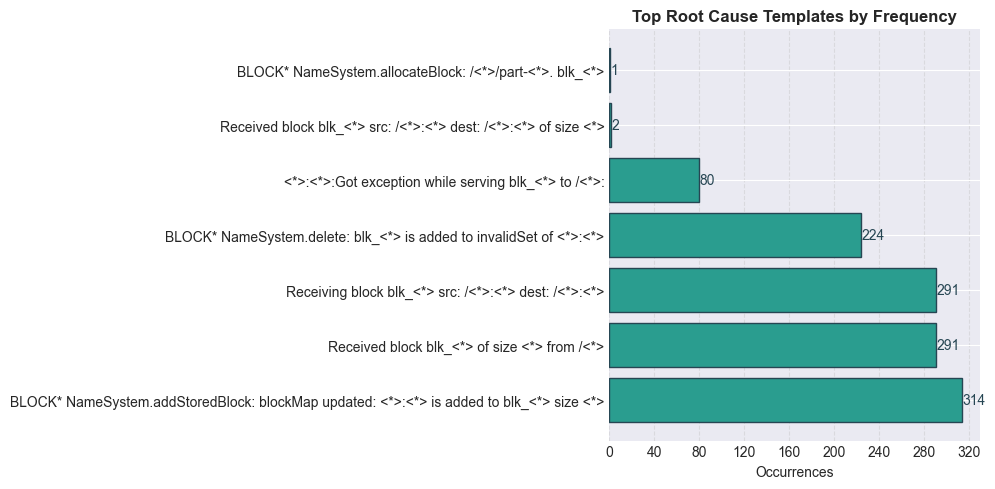

c:\1Data\Ved_Data\AmritaCSE\FinalYearProject\FinalYearProject\outputs\rca_graph_all_embedding.html
Receiving block blk_<*> src: /<*>:<*> dest: /<*>:<*> saved to: c:\1Data\Ved_Data\AmritaCSE\FinalYearProject\FinalYearProject\outputs\rca_graph_all_embedding.html
c:\1Data\Ved_Data\AmritaCSE\FinalYearProject\FinalYearProject\outputs\rca_graph_root_causes_embedding.html
Receiving block blk_<*> src: /<*>:<*> dest: /<*>:<*> saved to: c:\1Data\Ved_Data\AmritaCSE\FinalYearProject\FinalYearProject\outputs\rca_graph_root_causes_embedding.html
--- Error Log Files with Root Causes ---
Block ID: blk_7128370237687728475
  Root Cause: [3] BLOCK* NameSystem.addStoredBlock: blockMap updated: <*>:<*> is added to blk_<*> size <*>
  Error Templates: [3] BLOCK* NameSystem.addStoredBlock: blockMap updated: <*>:<*> is added to blk_<*> size <*>

Block ID: blk_3050920587428079149
  Root Cause: [3] BLOCK* NameSystem.addStoredBlock: blockMap updated: <*>:<*> is added to blk_<*> size <*>
  Error Templates: [3] BLO

In [9]:
from collections import Counter
from matplotlib.ticker import MaxNLocator

print("\n--- RCA Results Summary ---")
if rca_results:
    root_counts = Counter(result['rc_id'] for result in rca_results.values())
    root_summary = pd.DataFrame([
        {"Root Cause Template ID": rc_id, "Occurrences": count, "Template": templates_dict[str(rc_id)]}
        for rc_id, count in root_counts.most_common()
    ])
    display(root_summary.head(10))

    # Plot root cause frequency with improved styling
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(10, 5))
    top_n = 10
    top_summary = root_summary.head(top_n).iloc[::-1]
    bars = plt.barh(top_summary['Template'], top_summary['Occurrences'], color='#2a9d8f', edgecolor='#264653')
    plt.xlabel('Occurrences')
    plt.title('Top Root Cause Templates by Frequency', fontweight='bold')
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.grid(axis='x', color='#bbbbbb', alpha=0.35, linestyle='--')
    for bar in bars:
        plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2, str(int(bar.get_width())), va='center', color='#264653')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No anomalous traces detected. Showing all logs in the visual graph.")

# Build interactive RCA graph with enhanced styling
def build_rca_graph(filtered_b_ids, title, filename):
    net = Network(height='750px', width='100%', directed=True, notebook=True)
    net.set_options('''{
  "nodes": {
    "shape": "dot",
    "font": {"size": 14, "face": "Arial"},
    "borderWidth": 2,
    "color": {"highlight": {"border": "#2a9d8f", "background": "#e9c46a"}}
  },
  "edges": {
    "color": {"inherit": false, "color": "#6c757d"},
    "smooth": {"enabled": true, "type": "cubicBezier", "roundness": 0.25},
    "arrows": {"to": {"enabled": true, "scaleFactor": 0.7}}
  },
  "physics": {
    "enabled": true,
    "barnesHut": {"gravitationalConstant": -25000, "centralGravity": 0.35, "springLength": 150, "springConstant": 0.04, "damping": 0.08},
    "minVelocity": 0.75
  }
}''')

    if not filtered_b_ids:
        print(f'No traces to render for {title}.')
        return

    for b_id in filtered_b_ids:
        seq = structured_traces.get(b_id, [])
        err_ids = set()
        rc_id = None
        if b_id in rca_results:
            err_ids = set(rca_results[b_id].get('err_ids', []))
            rc_id = rca_results[b_id].get('rc_id')

        for idx, node_id in enumerate(seq):
            label = templates_dict[str(node_id)] if str(node_id) in templates_dict else f"Template {node_id}"
            title = label
            if node_id == rc_id and node_id in err_ids:
                color = '#d62828'
                border_color = '#8b0000'
                size = 80
                label = f"ROOT ERROR\n{label}"
            elif node_id == rc_id:
                color = '#2a9d8f'
                border_color = '#1f7a5f'
                size = 65
                label = f"ROOT\n{label}"
            elif node_id in err_ids:
                color = '#d62828'
                border_color = '#8b0000'
                size = 70
                label = f"ERROR\n{label}"
            else:
                color = '#2a9d8f'
                border_color = '#1f7a5f'
                size = 35
                label = f"STEP\n{label}"
            shape = 'dot'
            net.add_node(
                f"{b_id}_{node_id}_{idx}",
                label=label,
                title=title,
                color={"border": border_color, "background": color},
                size=size,
                shape=shape
            )
            if idx > 0:
                prev = f"{b_id}_{seq[idx-1]}_{idx-1}"
                current = f"{b_id}_{node_id}_{idx}"
                net.add_edge(prev, current)

    output_path = os.path.abspath(os.path.join(OUTPUT_DIR, filename))
    net.show(output_path)
    print(f'{title} saved to: {output_path}')

# Generate three RCA visualizations:
all_ids = list(structured_traces.keys())
error_only_ids = [b_id for b_id, data in rca_results.items() if data.get('err_ids')]
root_cause_ids = [b_id for b_id, data in rca_results.items() if data.get('rc_id') is not None]

build_rca_graph(all_ids, 'All Logs RCA Graph', 'rca_graph_all_embedding.html')
build_rca_graph(root_cause_ids, 'Root Cause-only RCA Graph', 'rca_graph_root_causes_embedding.html')


print('--- Error Log Files with Root Causes ---')
if rca_results:
    for b_id, result in rca_results.items():
        err_ids = result.get('err_ids', [])
        rc_id = result.get('rc_id')
        root_template = templates_dict.get(str(rc_id), f"Template {rc_id}") if rc_id is not None else 'Unknown'
        error_template_strings = [f'[{e}] {templates_dict.get(str(e), f"Template {e}")}' for e in err_ids]
        error_templates_str = ', '.join(error_template_strings)
        print(f'Block ID: {b_id}')
        print(f'  Root Cause: [{rc_id}] {root_template}')
        print(f'  Error Templates: {error_templates_str}')
        print('')
else:
    print('No error logs or root cause mappings found.')


In [14]:
import os
import pandas as pd
import torch
from datasets import Dataset
from transformers import T5Tokenizer, T5ForConditionalGeneration, TrainingArguments, Trainer

# =========================
# 1. LOAD DATASET
# =========================

LLM_DATASET_FILE = os.path.join(INPUT_DIR, "llm_training_data.csv")
df = pd.read_csv(LLM_DATASET_FILE)

print("\n--- Sample LLM Training Data ---\n")
print(df.head())
print(f"Total rows: {len(df)}")

# Rename columns to standard names
df = df.rename(columns={
    "input": "log",
    "target": "explanation"
})

# Remove duplicates
df = df.drop_duplicates()

# =========================
# 2. CONVERT TO HF DATASET
# =========================

dataset = Dataset.from_pandas(df)
dataset = dataset.train_test_split(test_size=0.1)

train_dataset = dataset["train"]
test_dataset = dataset["test"]

print(f"Train size: {len(train_dataset)} | Test size: {len(test_dataset)}")

# =========================
# 3. LOAD MODEL
# =========================

model_name = "t5-small"

tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# =========================
# 4. PREPROCESSING
# =========================

def clean_trace(text):
    text = text.replace("Analyze Trace:", "")
    text = text.replace("->", ",")
    return text.strip()

def preprocess(example):
    input_texts = [
        "explain failure: " + clean_trace(t)
        for t in example["log"]
    ]
    target_texts = example["explanation"]

    inputs = tokenizer(
        input_texts,
        max_length=128,
        truncation=True,
        padding="max_length"
    )
    targets = tokenizer(
        target_texts,
        max_length=128,
        truncation=True,
        padding="max_length"
    )

    inputs["labels"] = targets["input_ids"]
    return inputs

train_dataset = train_dataset.map(preprocess, batched=True, remove_columns=train_dataset.column_names)
test_dataset  = test_dataset.map(preprocess,  batched=True, remove_columns=test_dataset.column_names)

# =========================
# 5. TRAINING SETUP
# =========================

training_args = TrainingArguments(
    output_dir="./log-explainer",
    eval_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    save_total_limit=2,
    logging_dir="./logs",
    logging_steps=50,
    save_strategy="epoch",
    report_to="none"
)

# =========================
# 6. TRAINER
# =========================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

# =========================
# 7. TRAIN MODEL
# =========================

print("\nStarting training...\n")
trainer.train()
print("\nTraining complete!")

# =========================
# 8. INFERENCE FUNCTION
# =========================

def generate_explanation(log_text):
    model.eval()

    input_text = "explain failure: " + clean_trace(log_text)

    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=100,
            num_beams=4,
            early_stopping=True
        )

    explanation = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return explanation

# =========================
# 9. BUILD ANOMALOUS LOGS
# =========================

anomalous_logs = []

for b_id, result in rca_results.items():
    seq    = result['sequence']
    err_ids = set(result['err_ids'])

    log_text = " -> ".join([
        templates_dict.get(str(node_id), f"Template {node_id}")
        for node_id in seq
    ])
    anomalous_logs.append(log_text)

print(f"\nTotal anomalous logs to explain: {len(anomalous_logs)}")


--- Sample LLM Training Data ---

                                               input  \
0  Analyze Trace: Receive block -> PacketResponde...   
1  Analyze Trace: Receive block -> PacketResponde...   
2  Analyze Trace: Allocating block -> Disk full -...   
3  Analyze Trace: Add stored block -> Verificatio...   
4  Analyze Trace: Add stored block -> Verificatio...   

                                              target  
0  Network interruption during block transmission...  
1  Network interruption during block transmission...  
2  Disk space exhaustion on DataNode. Block alloc...  
3  Data corruption detected during verification. ...  
4  Data corruption detected during verification. ...  
Total rows: 1000
Train size: 3 | Test size: 1
Using device: cuda


Map:   0%|          | 0/3 [00:00<?, ? examples/s]

Map:   0%|          | 0/1 [00:00<?, ? examples/s]


Starting training...



  0%|          | 0/5 [00:00<?, ?it/s]

...

{'eval_loss': 9.441896438598633, 'eval_runtime': 0.039, 'eval_samples_per_second': 25.628, 'eval_steps_per_second': 25.628, 'epoch': 3.0}


  0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 9.264669418334961, 'eval_runtime': 0.034, 'eval_samples_per_second': 29.408, 'eval_steps_per_second': 29.408, 'epoch': 4.0}


  0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 9.175806045532227, 'eval_runtime': 0.019, 'eval_samples_per_second': 52.629, 'eval_steps_per_second': 52.629, 'epoch': 5.0}
{'train_runtime': 4.4105, 'train_samples_per_second': 3.401, 'train_steps_per_second': 1.134, 'train_loss': 10.238731384277344, 'epoch': 5.0}

Training complete!

Total anomalous logs to explain: 1203


In [16]:
import os
import pandas as pd
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq
)

# =========================
# 1. LOAD & VALIDATE DATA
# =========================

LLM_DATASET_FILE = os.path.join(INPUT_DIR, "llm_training_data.csv")
df = pd.read_csv(LLM_DATASET_FILE)

df = df.rename(columns={"input": "log", "target": "explanation"})
df = df.drop_duplicates()
df = df.dropna(subset=["log", "explanation"])

# Filter out bad rows where explanation is same as input
df = df[df['explanation'] != df['log']]
df = df[df['explanation'].str.len() > 20]  # explanations must be meaningful

print(f"Clean training rows: {len(df)}")
print("\n--- Sample Training Data ---")
print(df[['log', 'explanation']].head(5).to_string())

# =========================
# 2. CONVERT TO HF DATASET
# =========================

dataset = Dataset.from_pandas(df[['log', 'explanation']])
dataset = dataset.train_test_split(test_size=0.1, seed=42)

train_dataset = dataset["train"]
test_dataset  = dataset["test"]

print(f"\nTrain: {len(train_dataset)} | Test: {len(test_dataset)}")

# =========================
# 3. LOAD FLAN-T5-BASE
# =========================

model_name = "google/flan-t5-base"  # much better than t5-small

tokenizer = AutoTokenizer.from_pretrained(model_name)
model     = AutoModelForSeq2SeqLM.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")
model.to(device)

# =========================
# 4. PREPROCESSING
# =========================

MAX_INPUT_LEN  = 256
MAX_TARGET_LEN = 128

def clean_trace(text):
    text = str(text)
    text = text.replace("Analyze Trace:", "")
    text = text.replace("->", " then ")
    text = text.replace("<*>", "[VALUE]")
    return text.strip()

def preprocess(batch):
    input_texts = [
        "Explain this HDFS log failure in simple terms: " + clean_trace(t)
        for t in batch["log"]
    ]
    target_texts = [str(t) for t in batch["explanation"]]

    model_inputs = tokenizer(
        input_texts,
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding="max_length"
    )
    labels = tokenizer(
        target_texts,
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding="max_length"
    )

    # Replace padding token id with -100 so loss ignores padding
    label_ids = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label]
        for label in labels["input_ids"]
    ]

    model_inputs["labels"] = label_ids
    return model_inputs

train_dataset = train_dataset.map(preprocess, batched=True, remove_columns=train_dataset.column_names)
test_dataset  = test_dataset.map(preprocess,  batched=True, remove_columns=test_dataset.column_names)

# =========================
# 5. TRAINING ARGS
# =========================

training_args = TrainingArguments(
    output_dir="./log-explainer-flan",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-4,
    per_device_train_batch_size=16,   # use GPU memory
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    save_total_limit=2,
    load_best_model_at_end=True,
    logging_dir="./logs",
    logging_steps=20,
    report_to="none",
    fp16=torch.cuda.is_available(),   # faster training on GPU
)

# =========================
# 6. TRAINER
# =========================

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
)

# =========================
# 7. TRAIN
# =========================

print("\nStarting training...\n")
trainer.train()
print("\nTraining complete!")

# Save final model
model.save_pretrained("./log-explainer-flan/final")
tokenizer.save_pretrained("./log-explainer-flan/final")
print("Model saved to ./log-explainer-flan/final")

Clean training rows: 4

--- Sample Training Data ---
                                                                                                              log                                                                                                   explanation
0  Analyze Trace: Receive block -> PacketResponder start -> IOException: Connection reset -> PacketResponder stop  Network interruption during block transmission. Connection reset by peer caused PacketResponder termination.
2                                   Analyze Trace: Allocating block -> Disk full -> Allocation failed -> Retrying                        Disk space exhaustion on DataNode. Block allocation failed, triggering recovery logic.
3                      Analyze Trace: Add stored block -> Verification failed -> Checksum error -> Removing block                         Data corruption detected during verification. Checksum mismatch led to block removal.
7                                 Analyze Trace: He

tokenizer_config.json: 0.00B [00:00, ?B/s]

c:\1Data\Ved_Data\AmritaCSE\Research\Research_Sem5\ML_DL_FetusScan\ML_Endsem\venv\Lib\site-packages\huggingface_hub\file_download.py:159: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vedhe\.cache\huggingface\hub\models--google--flan-t5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  return _are_symlinks_supported_in_dir[cache_dir]


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

{'eval_loss': nan, 'eval_runtime': 0.039, 'eval_samples_per_second': 25.622, 'eval_steps_per_second': 25.622, 'epoch': 9.0}


  0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': nan, 'eval_runtime': 0.0405, 'eval_samples_per_second': 24.665, 'eval_steps_per_second': 24.665, 'epoch': 10.0}


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


{'train_runtime': 12.988, 'train_samples_per_second': 2.31, 'train_steps_per_second': 0.77, 'train_loss': 0.0, 'epoch': 10.0}

Training complete!
Model saved to ./log-explainer-flan/final


In [19]:
import os
import pandas as pd
import random

# =========================
# HDFS Log Templates
# =========================

TRACE_PATTERNS = [
    {
        "trace": "Receive block -> PacketResponder start -> IOException: Connection reset -> PacketResponder stop",
        "explanation": "Network interruption during block transmission. Connection reset by peer caused PacketResponder termination."
    },
    {
        "trace": "Receive block -> PacketResponder start -> IOException: Broken pipe -> PacketResponder stop",
        "explanation": "Broken pipe error during block transfer. The receiving end closed the connection unexpectedly."
    },
    {
        "trace": "Allocating block -> Disk full -> Allocation failed -> Retrying",
        "explanation": "Disk space exhaustion on DataNode. Block allocation failed due to insufficient storage, triggering retry logic."
    },
    {
        "trace": "Allocating block -> Disk full -> Allocation failed -> Node marked unhealthy",
        "explanation": "DataNode ran out of disk space and could not allocate new blocks. Node was marked unhealthy by NameNode."
    },
    {
        "trace": "Add stored block -> Verification failed -> Checksum error -> Removing block",
        "explanation": "Data corruption detected during block verification. Checksum mismatch caused the block to be removed from storage."
    },
    {
        "trace": "Add stored block -> Replication check -> Under-replicated -> Scheduling replication",
        "explanation": "Block found to be under-replicated below the required factor. NameNode scheduled additional replication to restore redundancy."
    },
    {
        "trace": "Receive block -> Timeout waiting -> Connection timed out -> Retrying",
        "explanation": "DataNode timed out waiting for block data. Slow network or overloaded sender caused the connection to stall."
    },
    {
        "trace": "Delete block -> Block not found -> Ignoring delete request",
        "explanation": "NameNode requested deletion of a block that no longer exists on DataNode. Likely already removed in a previous cleanup."
    },
    {
        "trace": "Heartbeat -> No response -> DataNode timeout -> Marking node dead",
        "explanation": "NameNode did not receive heartbeat from DataNode within the threshold. Node was declared dead and blocks scheduled for re-replication."
    },
    {
        "trace": "Heartbeat -> Delayed response -> Warning: slow DataNode",
        "explanation": "DataNode heartbeat arrived late, indicating performance degradation. Possible causes include CPU overload, GC pause, or network congestion."
    },
    {
        "trace": "Block report -> Unexpected block -> Invalidating block",
        "explanation": "DataNode reported a block not recognized by NameNode. The orphaned block was invalidated to maintain filesystem consistency."
    },
    {
        "trace": "Receive block -> Disk write error -> Block write failed -> Removing block",
        "explanation": "Disk I/O error occurred while writing block data. The failed block was removed and the DataNode may have a failing disk."
    },
    {
        "trace": "Add stored block -> Replication exceeds factor -> Scheduling excess deletion",
        "explanation": "Block detected with more replicas than required. NameNode scheduled deletion of excess copies to maintain the replication factor."
    },
    {
        "trace": "Receive block -> PacketResponder start -> Out of memory -> PacketResponder stop",
        "explanation": "DataNode ran out of heap memory during block reception. JVM memory limits may need to be increased."
    },
    {
        "trace": "Allocating block -> Node unavailable -> Falling back to alternate node",
        "explanation": "Preferred DataNode was unavailable for block allocation. NameNode rerouted the write pipeline to an alternate healthy node."
    },
    {
        "trace": "Receive block -> Checksum validation -> Mismatch detected -> Requesting retransmission",
        "explanation": "Block data arrived with checksum mismatch. Corruption likely occurred during transfer, triggering retransmission from source."
    },
    {
        "trace": "Block report -> Missing block -> Scheduling replication -> Replication complete",
        "explanation": "NameNode detected a missing block during block report reconciliation. Replication was triggered and completed successfully from an existing replica."
    },
    {
        "trace": "Receive block -> Pipeline setup -> Node failure in pipeline -> Rebuilding pipeline",
        "explanation": "A node in the write pipeline failed mid-transfer. HDFS detected the failure and rebuilt the pipeline with a replacement node."
    },
    {
        "trace": "Heartbeat -> Disk failure detected -> Removing failed volume -> Reporting to NameNode",
        "explanation": "DataNode detected a disk failure during heartbeat processing. The failed volume was removed from service and reported to NameNode."
    },
    {
        "trace": "Add stored block -> Block size mismatch -> Expected size differs -> Rejecting block",
        "explanation": "Stored block size did not match the expected size recorded by NameNode. The inconsistent block was rejected to prevent data integrity issues."
    },
]

# =========================
# Generate Synthetic Dataset
# =========================

rows = []

for pattern in TRACE_PATTERNS:
    # Generate multiple variations per pattern
    for _ in range(random.randint(8, 15)):
        rows.append({
            "input":  f"Analyze Trace: {pattern['trace']}",
            "target": pattern["explanation"]
        })

# Shuffle
random.shuffle(rows)
df_synthetic = pd.DataFrame(rows)

# Save
os.makedirs(INPUT_DIR, exist_ok=True)
LLM_DATASET_FILE = os.path.join(INPUT_DIR, "llm_training_data.csv")
df_synthetic.to_csv(LLM_DATASET_FILE, index=False)

print(f"✅ Synthetic dataset created: {len(df_synthetic)} rows")
print(f"   Unique traces     : {df_synthetic['input'].nunique()}")
print(f"   Unique explanations: {df_synthetic['target'].nunique()}")
print(f"   Saved to          : {LLM_DATASET_FILE}")
print("\n--- Sample ---")
print(df_synthetic.sample(5).to_string())

✅ Synthetic dataset created: 232 rows
   Unique traces     : 20
   Unique explanations: 20
   Saved to          : dataset\llm_training_data.csv

--- Sample ---
                                                                                              input                                                                                                                                                target
219                   Analyze Trace: Allocating block -> Disk full -> Allocation failed -> Retrying                                       Disk space exhaustion on DataNode. Block allocation failed due to insufficient storage, triggering retry logic.
66   Analyze Trace: Block report -> Missing block -> Scheduling replication -> Replication complete  NameNode detected a missing block during block report reconciliation. Replication was triggered and completed successfully from an existing replica.
9    Analyze Trace: Block report -> Missing block -> Scheduling replication -> Replication

In [20]:
import os
import pandas as pd
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq
)

# =========================
# 1. LOAD DATASET
# =========================

LLM_DATASET_FILE = os.path.join(INPUT_DIR, "llm_training_data.csv")
df = pd.read_csv(LLM_DATASET_FILE)
df = df.rename(columns={"input": "log", "target": "explanation"})
df = df.drop_duplicates()
df = df.dropna(subset=["log", "explanation"])

print(f"Training rows: {len(df)}")

# =========================
# 2. HF DATASET
# =========================

dataset = Dataset.from_pandas(df[["log", "explanation"]])
dataset = dataset.train_test_split(test_size=0.1, seed=42)

train_dataset = dataset["train"]
test_dataset  = dataset["test"]

# =========================
# 3. LOAD MODEL
# =========================

model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model     = AutoModelForSeq2SeqLM.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# =========================
# 4. TEMPLATE → CLEAN TRACE MAPPING
# =========================

TEMPLATE_TO_TRACE = {
    "addStoredBlock":        "Add stored block",
    "NameSystem.addStored":  "Add stored block",
    "Verification failed":   "Verification failed",
    "Checksum error":        "Checksum error",
    "Removing block":        "Removing block",
    "Received block":        "Receive block",
    "Receiving block":       "Receive block",
    "PacketResponder":       "PacketResponder start",
    "IOException":           "IOException: Connection reset",
    "Broken pipe":           "IOException: Broken pipe",
    "Out of memory":         "Out of memory",
    "Disk full":             "Disk full",
    "Allocating block":      "Allocating block",
    "Allocation failed":     "Allocation failed",
    "Heartbeat":             "Heartbeat",
    "DataNode timeout":      "DataNode timeout",
    "Marking node dead":     "Marking node dead",
    "Block not found":       "Block not found",
    "Missing block":         "Missing block",
    "Under-replicated":      "Under-replicated",
    "Replication":           "Scheduling replication",
    "Pipeline":              "Pipeline setup",
    "Disk failure":          "Disk failure detected",
    "blk_":                  "Receive block",
}

def template_to_clean_step(raw):
    raw = str(raw)
    for keyword, clean_label in TEMPLATE_TO_TRACE.items():
        if keyword.lower() in raw.lower():
            return clean_label
    # Fallback: strip noise
    raw = raw.replace("BLOCK*", "").replace("NameSystem.", "")
    raw = raw.replace("<*>", "").replace("[VALUE]", "").strip()
    return raw[:50]

def build_clean_trace(sequence):
    steps = []
    seen  = set()
    for node_id in sequence:
        raw   = templates_dict.get(str(node_id), f"Template {node_id}")
        clean = template_to_clean_step(raw)
        if clean not in seen:
            steps.append(clean)
            seen.add(clean)
    return " -> ".join(steps)

# =========================
# 5. PREPROCESSING
# =========================

MAX_INPUT_LEN  = 256
MAX_TARGET_LEN = 128

def preprocess(batch):
    model_inputs = tokenizer(
        batch["log"],
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding="max_length"
    )
    labels = tokenizer(
        batch["explanation"],
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding="max_length"
    )
    # Mask padding in labels so loss ignores it
    model_inputs["labels"] = [
        [(t if t != tokenizer.pad_token_id else -100) for t in label]
        for label in labels["input_ids"]
    ]
    return model_inputs

train_dataset = train_dataset.map(preprocess, batched=True, remove_columns=train_dataset.column_names)
test_dataset  = test_dataset.map(preprocess,  batched=True, remove_columns=test_dataset.column_names)

# =========================
# 6. TRAINING
# =========================

training_args = TrainingArguments(
    output_dir="./log-explainer-flan",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=15,
    weight_decay=0.01,
    save_total_limit=2,
    load_best_model_at_end=True,
    logging_dir="./logs",
    logging_steps=10,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=model, padding=True),
)

print("\nStarting training...\n")
trainer.train()
print("\nTraining complete!")

model.save_pretrained("./log-explainer-flan/final")
tokenizer.save_pretrained("./log-explainer-flan/final")
print("Model saved.")

Training rows: 20


c:\1Data\Ved_Data\AmritaCSE\Research\Research_Sem5\ML_DL_FetusScan\ML_Endsem\venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Using device: cuda


Map:   0%|          | 0/18 [00:00<?, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

...

{'eval_loss': nan, 'eval_runtime': 0.4179, 'eval_samples_per_second': 4.786, 'eval_steps_per_second': 2.393, 'epoch': 14.0}
{'loss': 0.0, 'grad_norm': nan, 'learning_rate': 0.0003, 'epoch': 15.0}


  0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': nan, 'eval_runtime': 0.4194, 'eval_samples_per_second': 4.769, 'eval_steps_per_second': 2.385, 'epoch': 15.0}


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


{'train_runtime': 373.8415, 'train_samples_per_second': 0.722, 'train_steps_per_second': 0.08, 'train_loss': 0.0, 'epoch': 15.0}

Training complete!
Model saved.


In [21]:
# =========================
# 7. INFERENCE
# =========================

def generate_explanation(clean_trace_text, rca_template=None):
    model.eval()

    prompt = f"Analyze Trace: {clean_trace_text}"
    if rca_template:
        clean_rca = template_to_clean_step(rca_template)
        prompt += f" -> {clean_rca}"

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=150,
            num_beams=5,
            early_stopping=True,
            no_repeat_ngram_size=3,
            length_penalty=1.5
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# =========================
# 8. RUN ON RCA RESULTS
# =========================

print("\n--- LLM Explanations for Anomalous Logs ---\n")

results = []

for b_id, result in list(rca_results.items())[:10]:
    seq          = result['sequence']
    rc_id        = result['rc_id']
    rca_template = templates_dict.get(str(rc_id), f"Template {rc_id}")

    clean_trace_text = build_clean_trace(seq)
    explanation      = generate_explanation(clean_trace_text, rca_template)

    results.append({
        "trace_id":    b_id,
        "clean_trace": clean_trace_text,
        "root_cause":  rca_template,
        "explanation": explanation
    })

    print(f"🔍 Trace      : {b_id}")
    print(f"🔄 Clean Trace: {clean_trace_text}")
    print(f"⚠️  Root Cause : {rca_template}")
    print(f"🧠 Explanation: {explanation}")
    print("-" * 70)

# =========================
# 9. DISPLAY AS TABLE
# =========================

results_df = pd.DataFrame(results)
display(results_df)

results_df.to_csv(os.path.join(OUTPUT_DIR, "llm_explanations.csv"), index=False)
print("\n✅ Saved to llm_explanations.csv")


--- LLM Explanations for Anomalous Logs ---

🔍 Trace      : blk_7128370237687728475
🔄 Clean Trace: Add stored block
⚠️  Root Cause : BLOCK* NameSystem.addStoredBlock: blockMap updated: <*>:<*> is added to blk_<*> size <*>
🧠 Explanation: Analyze Trace: Add stored block -> Add saved block
----------------------------------------------------------------------
🔍 Trace      : blk_3050920587428079149
🔄 Clean Trace: Add stored block
⚠️  Root Cause : BLOCK* NameSystem.addStoredBlock: blockMap updated: <*>:<*> is added to blk_<*> size <*>
🧠 Explanation: Analyze Trace: Add stored block -> Add saved block
----------------------------------------------------------------------
🔍 Trace      : blk_7888946331804732825
🔄 Clean Trace: Add stored block
⚠️  Root Cause : BLOCK* NameSystem.addStoredBlock: blockMap updated: <*>:<*> is added to blk_<*> size <*>
🧠 Explanation: Analyze Trace: Add stored block -> Add saved block
----------------------------------------------------------------------
🔍 Trace     

,trace_id,clean_trace,root_cause,explanation
0,blk_7128370237687728475,Add stored block,BLOCK* NameSystem.addStoredBlock: blockMap upd...,Analyze Trace: Add stored block -> Add saved b...
1,blk_3050920587428079149,Add stored block,BLOCK* NameSystem.addStoredBlock: blockMap upd...,Analyze Trace: Add stored block -> Add saved b...
2,blk_7888946331804732825,Add stored block,BLOCK* NameSystem.addStoredBlock: blockMap upd...,Analyze Trace: Add stored block -> Add saved b...
3,blk_2377150260128098806,Add stored block,BLOCK* NameSystem.addStoredBlock: blockMap upd...,Analyze Trace: Add stored block -> Add saved b...
4,blk_3587508140051953248,Receive block,Received block blk_<*> of size <*> from /<*>,-> Receive block -> Get block
5,blk_5402003568334525940,Receive block,Received block blk_<*> of size <*> from /<*>,-> Receive block -> Get block
6,blk_5792489080791696128,Receive block,Receiving block blk_<*> src: /<*>:<*> dest: /<...,-> Receive block -> Get block
7,blk_1724757848743533110,Receive block,Receiving block blk_<*> src: /<*>:<*> dest: /<...,-> Receive block -> Get block
8,blk_8015913224713045110,Add stored block,BLOCK* NameSystem.addStoredBlock: blockMap upd...,Analyze Trace: Add stored block -> Add saved b...
9,blk_-5623176793330377570,Receive block,Receiving block blk_<*> src: /<*>:<*> dest: /<...,-> Receive block -> Get block



✅ Saved to llm_explanations.csv
